In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\leela\OneDrive\Desktop\PORTFOLIO PROJECTS\Loan\Train.csv")  # change filename if different

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [8]:
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df['Loan_Status'].value_counts()
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [4]:
# Categorical (mode)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Numerical (median/mode)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Confirm missing values
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [5]:
df['Loan_Status'].value_counts()
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

In [4]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [5]:
pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100

Loan_Status,N,Y
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


In [8]:
table = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
) * 100

table = table.rename(columns={
    'Y': 'Approved (%)',
    'N': 'Rejected (%)'
})

table

Loan_Status,Rejected (%),Approved (%)
Credit_History,,
0.0,92.134831,7.865169
1.0,20.421053,79.578947


In [7]:
table.index = table.index.map({
    0: "Bad Credit",
    1: "Good Credit"
})

table

Loan_Status,Rejected (%),Approved (%)
Credit_History,,
Bad Credit,92.134831,7.865169
Good Credit,20.421053,79.578947


In [15]:
pd.crosstab(df['Education'], df['Loan_Status'], normalize='index') * 100

Loan_Status,Approved,Rejected
Education,,
Graduate,70.833333,29.166667
Not Graduate,61.194030,38.805970


In [14]:
pd.crosstab(df['Property_Area'], df['Loan_Status'], normalize='index') * 100

Loan_Status,Approved,Rejected
Property_Area,,
Rural,61.452514,38.547486
Semiurban,76.824034,23.175966
Urban,65.841584,34.158416


In [13]:
df.groupby('Loan_Status')['ApplicantIncome'].mean()

Loan_Status
Approved    5384.068720
Rejected    5446.078125
Name: ApplicantIncome, dtype: float64

In [12]:
df['Loan_Status'] = df['Loan_Status'].map({
    'Y': 'Approved',
    'N': 'Rejected'
})

In [16]:
df.groupby('Loan_Status')['LoanAmount'].mean()

Loan_Status
Approved    143.869668
Rejected    149.890625
Name: LoanAmount, dtype: float64

In [17]:
pd.crosstab(df['Married'], df['Loan_Status'], normalize='index') * 100

Loan_Status,Approved,Rejected
Married,,
No,62.910798,37.089202
Yes,71.608040,28.391960


In [18]:
pd.crosstab(df['Self_Employed'], df['Loan_Status'], normalize='index') * 100

Loan_Status,Approved,Rejected
Self_Employed,,
No,68.600000,31.400000
Yes,68.292683,31.707317


In [19]:
pd.crosstab(df['Dependents'], df['Loan_Status'], normalize='index') * 100

Loan_Status,Approved,Rejected
Dependents,,
0,68.985507,31.014493
1,64.705882,35.294118
2,75.247525,24.752475
3+,64.705882,35.294118


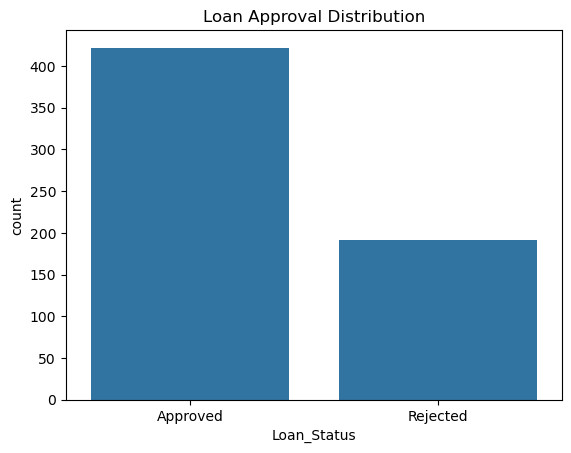

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

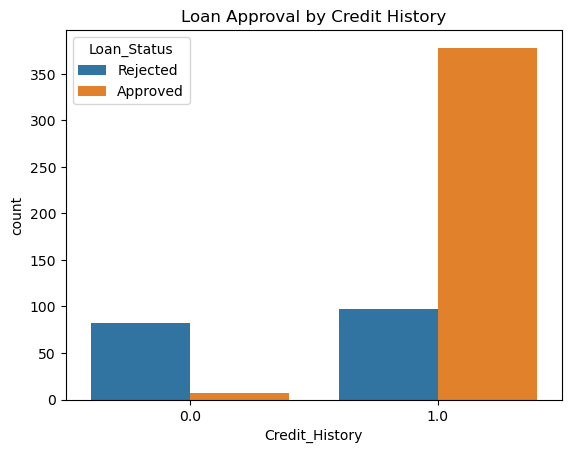

In [21]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)

plt.title("Loan Approval by Credit History")

plt.show()

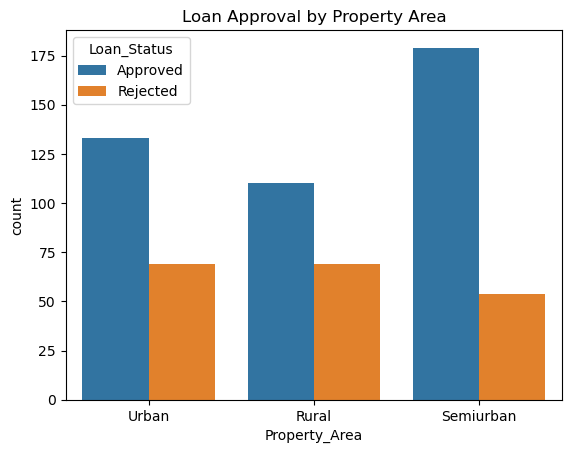

In [22]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.title("Loan Approval by Property Area")

plt.show()

<Axes: xlabel='Property_Area', ylabel='count'>

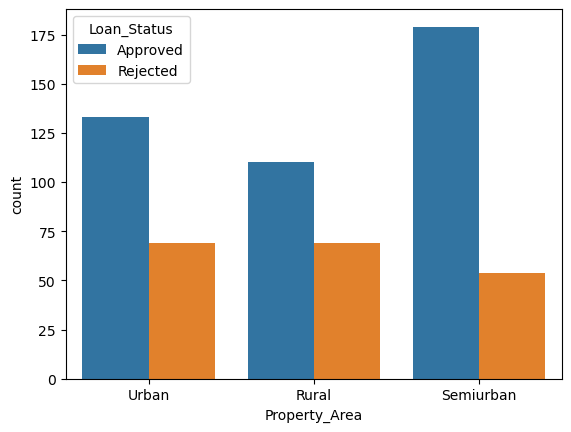

In [23]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

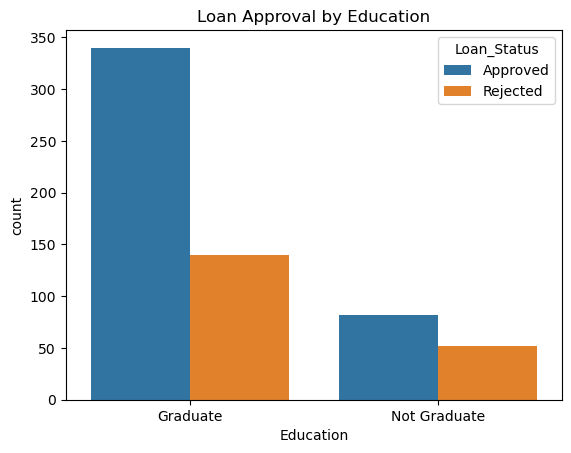

In [24]:
sns.countplot(x='Education', hue='Loan_Status', data=df)

plt.title("Loan Approval by Education")

plt.show()

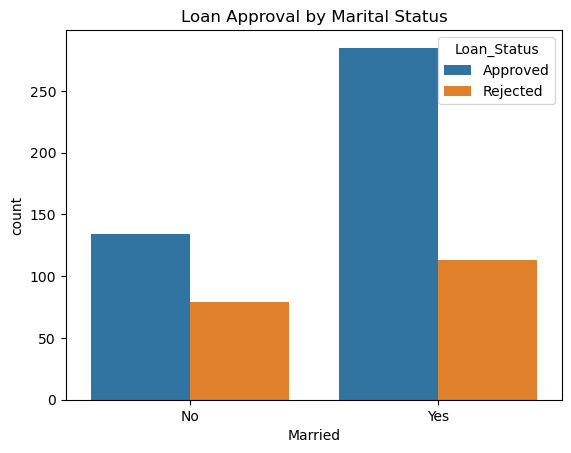

In [25]:
sns.countplot(x='Married', hue='Loan_Status', data=df)

plt.title("Loan Approval by Marital Status")

plt.show()

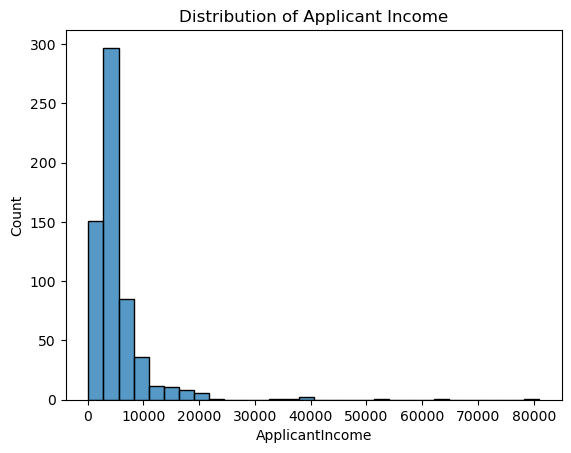

In [26]:
sns.histplot(df['ApplicantIncome'], bins=30)

plt.title("Distribution of Applicant Income")

plt.show()

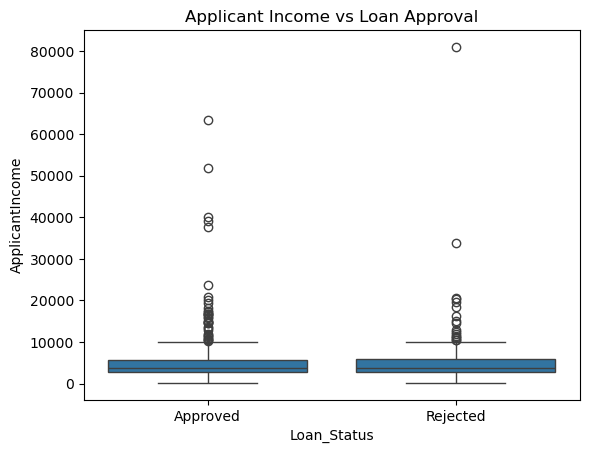

In [27]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)

plt.title("Applicant Income vs Loan Approval")

plt.show()

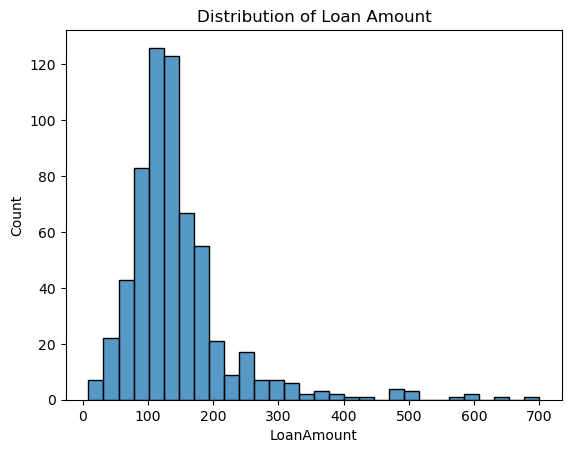

In [28]:
sns.histplot(df['LoanAmount'], bins=30)

plt.title("Distribution of Loan Amount")

plt.show()

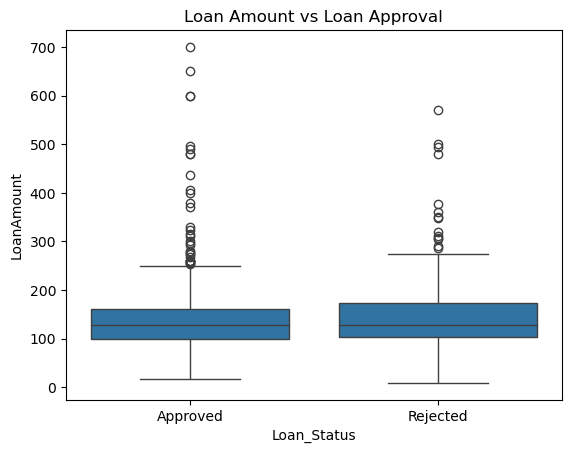

In [29]:
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)

plt.title("Loan Amount vs Loan Approval")

plt.show()

In [30]:
df.to_csv("cleaned_loan_data.csv", index=False)